In [15]:
with open("/content/cipher.txt", "r", encoding="windows-1251") as f:
    cipher_text = f.read()

with open("/content/potter.txt", "r", encoding="windows-1251") as f:
    text = f.read()

In [16]:
abc = "abcdefghijklmnopqrstuvwxyz"
#abc = sorted(abc)
len(abc)
lenth = len(list(cipher_text))

In [17]:
from matplotlib import pyplot as plt

In [18]:
def compute_correlation(cipher_text):
    counts = []
    for k in range(256): #len(cipher_text)):
        count = 0
        for a, b in zip(cipher_text[:-k], cipher_text[k:]):
            if a == b:
                count += 1
        counts.append(count)
    return counts

counts = compute_correlation(cipher_text)

<BarContainer object of 25 artists>

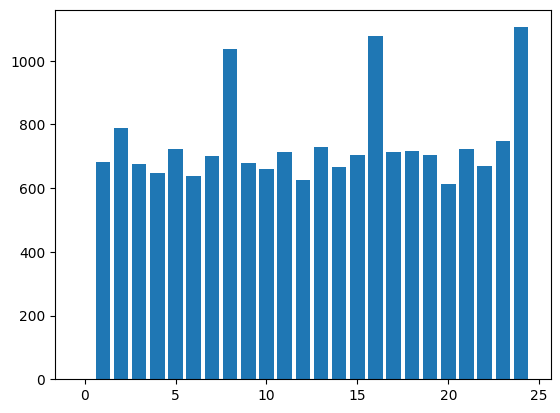

In [19]:
plt.bar(range(25), counts[:25])

In [20]:
n = 8

In [21]:
text = text.lower()
statistics2 = {letter: 0 for letter in abc}
for letter in abc:
    statistics2[letter] = text.count(letter)

In [22]:
cipher_text = cipher_text.lower()
statistics1 = {letter: 0 for letter in abc}
for letter in abc:
    statistics1[letter] = cipher_text.count(letter)

<BarContainer object of 26 artists>

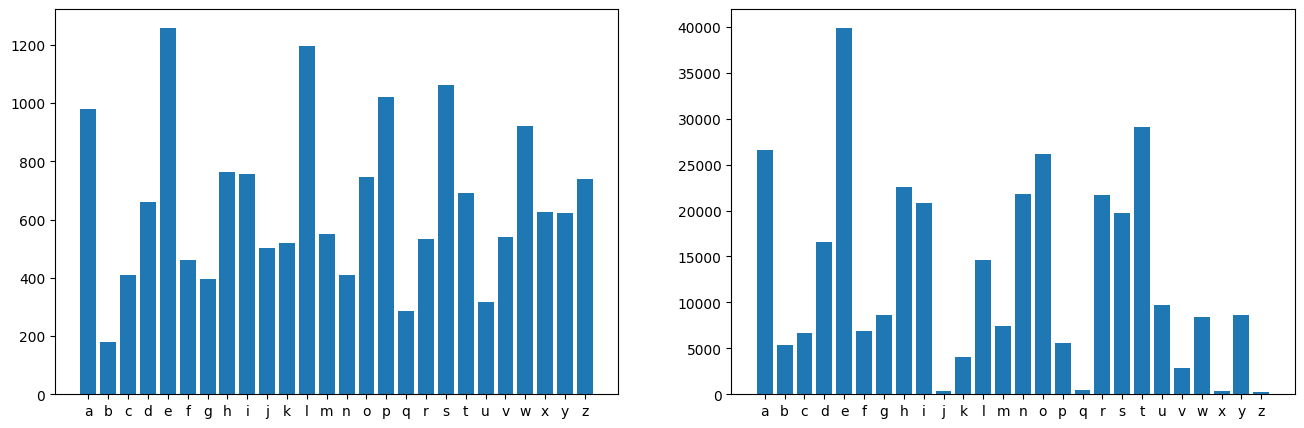

In [23]:
from matplotlib import pyplot as plt
fig, axs = plt.subplots(1,2, figsize=(16,5))
axs[0].bar(x=statistics1.keys(), height=statistics1.values())
axs[1].bar(x=statistics2.keys(), height=statistics2.values())

In [24]:
def find_key(cipher_text, n, alphabet, plain_stats):
    key = []

    pop_plain = max(plain_stats, key=plain_stats.get)
    idx_plain = alphabet.index(pop_plain)

    for i in range(n):
        group = cipher_text[i::n]
        group_stats = {letter: 0 for letter in alphabet}
        for k in group:
            if k.lower() in alphabet:
                group_stats[k.lower()] += 1
        pop_cipher = max(group_stats, key=group_stats.get)
        idx_cipher = alphabet.index(pop_cipher)
        shift = (idx_cipher - idx_plain)
        if shift < 0:
          shift+=26
        key.append(shift)
    return key


In [25]:
keyword = find_key(cipher_text, n, abc, statistics2)
print(f"Результат: {keyword}")

Результат: [7, 4, 0, 11, 0, 22, 4, 18]


In [26]:
keyword = [7, 4, 11, 11, 0, 22, 4, 18]

In [27]:
import string

In [28]:
class caesar:
  @staticmethod #эти фунции относятся к классу этому, а другие функции к другому классу
  def encrypt_caesar(plaintext:str, shift):
    lower = string.ascii_lowercase
    upper = string.ascii_uppercase
    table = str.maketrans(lower + upper, lower[shift:] + lower[:shift] + upper[shift:] + upper[:shift])
    return plaintext.translate(table)

  @staticmethod
  def decrypt_caesar(chiphertext, shift):
    return caesar.encrypt_caesar(chiphertext, -shift)

In [29]:
class vigenere:
    @staticmethod
    def decrypt_vigenere(cipher_text: str, keyword):
        n = len(keyword)
        text_list = list(cipher_text)

        for i in range(n):
            shift = keyword[i]
            part = "".join(text_list[i::n])
            decrypted_part = caesar.encrypt_caesar(part, -shift)
            text_list[i::n] = list(decrypted_part)
        return "".join(text_list)

In [31]:
result = vigenere.decrypt_vigenere(cipher_text, keyword)
print(result)
with open('cracked.txt', 'w') as file:
    file.write(result)

“surelyyou’rejoking,mr.feynman!”:adventuresofacuriouscharacterbyrichardp.feynman
part1.fromfarrockawaytomit
hefixesradiosbythinking!
wheniwasaboutelevenortwelveisetupalabinmyhouse.itconsistedofanoldwoodenpackingboxthatiputshelvesin.ihadaheater,andi’dputinfatandcookfrench-friedpotatoesallthetime.ialsohadastoragebattery,andalampbank.
tobuildthelampbankiwentdowntothefive-and-tenandgotsomesocketsyoucanscrewdowntoawoodenbase,andconnectedthemwithpiecesofbellwire.bymakingdifferentcombinationsofswitches—inseriesorparallel—iknewicouldgetdifferentvoltages.butwhatihadn’trealizedwasthatabulb’sresistancedependsonitstemperature,sotheresultsofmycalculationsweren’tthesameasthestuffthatcameoutofthecircuit.butitwasallright,andwhenthebulbswereinseries,allhalf-lit,theywouldgloooooooooow,verypretty—itwasgreat!
ihadafuseinthesystemsoifishortedanything,thefusewouldblow.nowihadtohaveafusethatwasweakerthanthefuseinthehouse,soimademyownfusesbytakingtinfoilandwrappingitaroundanoldburnt-outfuse.acrossmyfuseihadaf